好的，这是一首关于猫的诗：

**慵懒的哲学家**

身披丝绒，步履轻盈，
一团慵懒，一抹精灵。
卧于窗台，沐浴暖阳，
梦境轻浅，岁月绵长。

眸若琥珀，深邃如渊，
藏着宇宙，也藏着禅。
忽而警觉，耳尖微颤，
捕捉风声，或叶落翩。

弓背伸展，曲线优美，
悄然穿梭，不惹尘灰。
爪藏利刃，软垫无声，
扑击玩伴，眼神认真。

忽而亲昵，蹭你衣角，
忽而独立，不求缠绕。
一声咕噜，低沉回响，
是满足，是温柔的谎。

它是伙伴，也是哲人，
独享世间，自在随心。
猫，一个谜，一首诗，
永远优雅，永远真实。


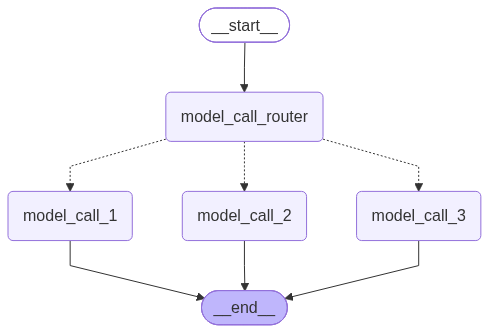

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model_call_1(model_call_1)
	model_call_2(model_call_2)
	model_call_3(model_call_3)
	model_call_router(model_call_router)
	__end__([<p>__end__</p>]):::last
	__start__ --> model_call_router;
	model_call_router -.-> model_call_1;
	model_call_router -.-> model_call_2;
	model_call_router -.-> model_call_3;
	model_call_1 --> __end__;
	model_call_2 --> __end__;
	model_call_3 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [1]:
from pydantic import BaseModel, Field
from typing import Literal,TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage, SystemMessage

from langchain_deepseek import ChatDeepSeek

import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv(override=True)
from rich import print as rprint

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

# 定义用于结构化输出的 Schema，作为路由判断依据
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None,
        description="路由流程中的下一执行步骤",
    )

# 为大模型添加结构化输出能力
router = model.with_structured_output(Route)

# 图状态
class OverAllState(TypedDict):
    input: str
    decision: str
    output: str

# 节点
def model_call_1(state: OverAllState) -> OverAllState:
    """生成故事"""

    result = model.invoke(
        [HumanMessage(content=state["input"])]
    )
    return {"output": result.content}


def model_call_2(state: OverAllState) -> OverAllState:
    """生成笑话"""

    result = model.invoke(
        [HumanMessage(content=state["input"])]
    )
    return {"output": result.content}


def model_call_3(state: OverAllState) -> OverAllState:
    """生成诗歌"""

    result = model.invoke(
        [HumanMessage(content=state["input"])]
    )
    return {"output": result.content}


def model_call_router(state: OverAllState) -> OverAllState:
    """将用户输入路由到合适的节点"""

    # 调用具有结构化输出能力的大模型，完成路由判断
    decision = router.invoke(
        [
            SystemMessage(
                content=(
                    "根据用户的请求，将其路由到 story、joke 或 poem。"
                    "请求编写故事时返回 story，请求编写笑话时返回 joke，"
                    "请求编写诗歌时返回 poem。"
                )
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# 条件边函数：根据路由决策选择下一个节点
def route_decision(
        state: OverAllState
) -> Literal[
    "model_call_1",
    "model_call_2",
    "model_call_3",
    END
]:
    # 返回接下来要执行的节点名称
    if state["decision"] == "story":
        return "model_call_1"
    elif state["decision"] == "joke":
        return "model_call_2"
    elif state["decision"] == "poem":
        return "model_call_3"
    return END


# 构建工作流
builder = StateGraph(OverAllState)

# 添加节点
builder.add_node("model_call_1", model_call_1)
builder.add_node("model_call_2", model_call_2)
builder.add_node("model_call_3", model_call_3)
builder.add_node("model_call_router", model_call_router)

# 添加边，连接各个节点
builder.add_edge(START, "model_call_router")
builder.add_conditional_edges(
    "model_call_router",
    route_decision,
    {
        # route_decision 返回的名称：接下来要执行的节点名称
        "model_call_1": "model_call_1",
        "model_call_2": "model_call_2",
        "model_call_3": "model_call_3",
    },
)
builder.add_edge("model_call_1", END)
builder.add_edge("model_call_2", END)
builder.add_edge("model_call_3", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
state = graph.invoke({"input": "写一个关于猫的诗"})
print(state["output"])

# 显示工作流图
from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)